# Collect Radar Coverage (NEXRAD, Phoenix AZ Region)

This example demonstrates how to use direct function calls of the low-level TAT-C library to collect ground-based radar coverage footprints, using the `RadarStation` schema and the `collect_radar_track`/`compute_radar_track` analysis functions. Unlike a satellite's ground track, a radar station does not move, so these functions report a single static coverage footprint per station rather than a time series.

The first examples do not use a terrain mask: coverage is assumed to be azimuthally symmetric (an idealized, unobstructed line of sight in every direction). A later section adds DEM-derived terrain masks to model terrain blockage.

The first step is to define the NEXRAD (WSR-88D) weather radar stations serving the broader Phoenix, Arizona region: `KIWA` (Phoenix/Mesa), `KFSX` (Flagstaff), `KYUX` (Yuma), and `KEMX` (Tucson). Station coordinates and elevations below are taken from NOAA's official station table, the [NCEI Historical Observing Metadata Repository NEXRAD list](https://www.ncei.noaa.gov/access/homr/file/nexrad-stations.txt), whose elevations are antenna heights (converted here from feet to meters) and agree within about 1 m with the ground elevation plus tower height reported in each radar's own Level II data. These heights are above mean sea level, the same reference as the digital elevation model used for terrain masks below; they differ from heights above the WGS 84 ellipsoid by the geoid undulation (about -30 m in this region), which does not change coverage as long as target elevations use the same reference.

Other parameters (`max_range`, `min_elevation_angle`, `max_elevation_angle`, `beam_width`) use `RadarStation`'s NEXRAD-typical defaults (460 km, the range of NEXRAD Level II reflectivity on its lowest tilts; 0.5 degrees; 19.5 degrees; and 0.95 degrees, respectively), except that `KFSX`, sited on a mountaintop, scans its lowest tilt slightly below local horizontal, at about -0.2 degrees. Coverage extends half the beam width below the lowest scanned beam center and above the highest, since echoes are received from across the whole half-power beam.

In [1]:
from tatc.schemas import RadarBand, RadarStation

# all four are real NEXRAD WSR-88D stations, which are S-band; coordinates and
# antenna elevations (1426, 7514, 239, and 5319 ft) are from the NCEI station table
stations = [
    RadarStation.from_band(RadarBand.S, name="KIWA", latitude=33.289233, longitude=-111.66991, elevation=434.6),
    RadarStation.from_band(
        RadarBand.S, name="KFSX", latitude=34.574333, longitude=-111.19844, elevation=2290.3, min_elevation_angle=-0.2
    ),
    RadarStation.from_band(RadarBand.S, name="KYUX", latitude=32.495281, longitude=-114.65671, elevation=72.8),
    RadarStation.from_band(RadarBand.S, name="KEMX", latitude=31.89365, longitude=-110.63025, elevation=1621.2),
]

The `collect_radar_track` method computes each station's coverage footprint at a specified target elevation, in the same vertical reference as the station elevations (here, mean sea level). Results are formatted as a flat GeoDataFrame, similar to a regular pandas DataFrame with a geospatial column labeled `geometry`. Other columns:
 * `station`: station name
 * `band`: station radar band (`RadarBand`), if specified
 * `elevation`: target elevation (m) used to compute the footprint
 * `inner_ground_range` / `outer_ground_range`: the idealized, azimuthally symmetric ground-range bounds (m) of the footprint, ignoring any terrain mask (NaN if the target elevation is not observable)

The target elevation is required: it is an absolute elevation common to all stations, not a height relative to each station. At 2,438 m (8,000 ft), just above the highest antenna (`KFSX`, 2,290 m), every station observes the target out to where the lower edge of its lowest beam climbs above that elevation, so the footprint size depends on how far the target is above the antenna. `KFSX`, whose lowest beam points slightly below local horizontal, has the largest footprint. (A radar observes targets below its antenna only where its lowest beam points below local horizontal, and then only down to the lowest point of that beam: at 1,500 m, for example, `KFSX` and `KEMX` would have no coverage.)

In [2]:
from tatc.analysis import collect_radar_track

results = collect_radar_track(stations, elevation=2438)
display(results)

,station,band,elevation,inner_ground_range,outer_ground_range,geometry
0,KIWA,S,2438,5505.570254,180802.373161,"POLYGON Z ((-109.73626 33.13004 2438, -109.764..."
1,KFSX,S,2438,406.320203,211987.571129,"POLYGON Z ((-108.8968 34.38768 2438, -108.9301..."
2,KYUX,S,2438,6498.517078,196762.050317,"POLYGON Z ((-112.57115 32.32203 2438, -112.601..."
3,KEMX,S,2438,2246.156874,114147.356030,"POLYGON Z ((-109.42833 31.79314 2438, -109.445..."


The results can be visualized using a plot, zoomed in on the Phoenix/Arizona region.

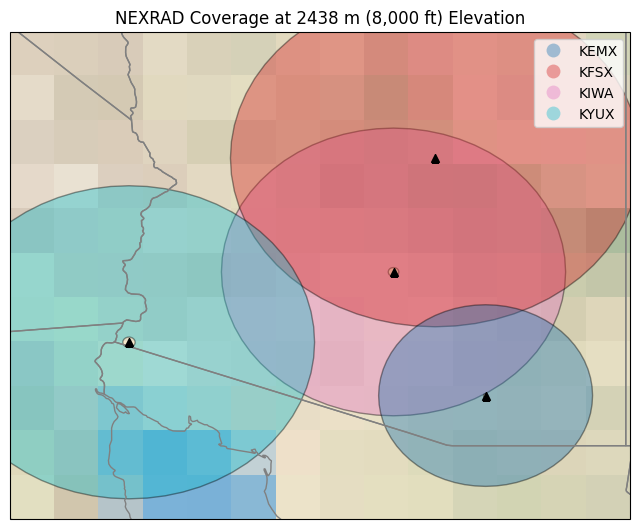

In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.PlateCarree()})

results.plot(
    column="station",
    edgecolor="k",
    alpha=0.4,
    legend=True,
    cmap="tab10",
    ax=ax,
    transform=ccrs.PlateCarree(),
)
ax.plot(
    [station.longitude for station in stations],
    [station.latitude for station in stations],
    "k^",
    transform=ccrs.PlateCarree(),
)
ax.stock_img()
ax.add_feature(cfeature.STATES, edgecolor="gray")
ax.set_extent([-116, -109, 30.5, 36], crs=ccrs.PlateCarree())
ax.set_title("NEXRAD Coverage at 2438 m (8,000 ft) Elevation")
plt.show()

Radar coverage depends strongly on target elevation, since a scanned beam climbs away from the surface with increasing range (due to Earth curvature and the standard-atmosphere refraction model). At a higher target elevation, e.g. 3048 m (10,000 ft) above mean sea level, each footprint's inner "cone of silence" widens (the station's highest scan tilt takes longer to climb to that height), while its outer boundary moves outward (the lowest scan tilt climbs to that height farther away) until it reaches the station's maximum range.

,station,band,elevation,inner_ground_range,outer_ground_range,geometry
0,KIWA,S,3048,7179.459799,207012.125126,"POLYGON Z ((-109.45596 33.10696 3048, -109.487..."
1,KFSX,S,3048,2083.704282,251358.100041,"POLYGON Z ((-108.46934 34.35301 3048, -108.508..."
2,KYUX,S,3048,8171.727439,221117.251564,"POLYGON Z ((-112.313 32.30059 3048, -112.34692..."
3,KEMX,S,3048,3922.278828,152020.047272,"POLYGON Z ((-109.02955 31.7598 3048, -109.0527..."


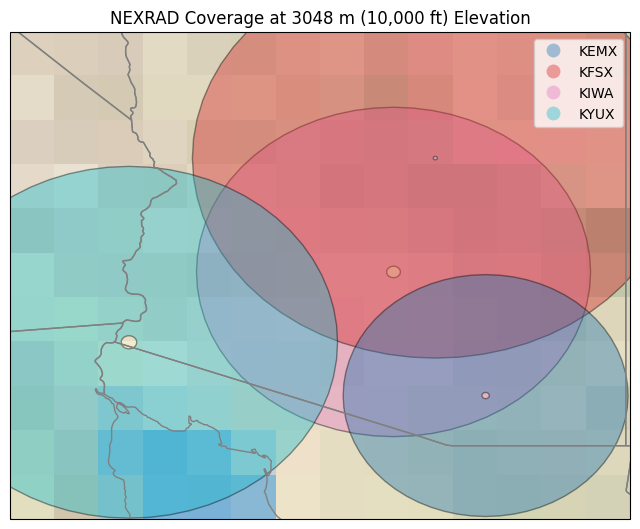

In [4]:
results_10kft = collect_radar_track(stations, elevation=3048)
display(results_10kft)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.PlateCarree()})
results_10kft.plot(
    column="station",
    edgecolor="k",
    alpha=0.4,
    legend=True,
    cmap="tab10",
    ax=ax,
    transform=ccrs.PlateCarree(),
)
ax.stock_img()
ax.add_feature(cfeature.STATES, edgecolor="gray")
ax.set_extent([-116, -109, 30.5, 36], crs=ccrs.PlateCarree())
ax.set_title("NEXRAD Coverage at 3048 m (10,000 ft) Elevation")
plt.show()

The results can also be processed using `compute_radar_track` to dissolve the individual station footprints into a single composite regional coverage geometry. This uses a target elevation of 3048 m (10,000 ft) above mean sea level, analogous to the 10,000 ft above-ground-level benchmark used in NOAA/NWS coverage maps of NEXRAD network gaps: most precipitation processes relevant to surface weather (rain/snow detection, severe-weather signatures) occur below this altitude, so gaps in coverage there are operationally significant, particularly over complex terrain. (Note this example measures it relative to mean sea level, not each location's local ground level, so it corresponds to a smaller height above ground at higher-elevation stations like `KFSX` or `KEMX` than at lower-elevation ones like `KYUX`.) The composite view also shows a station's "cone of silence" wherever no neighboring station's coverage fills it (here, at `KYUX`).

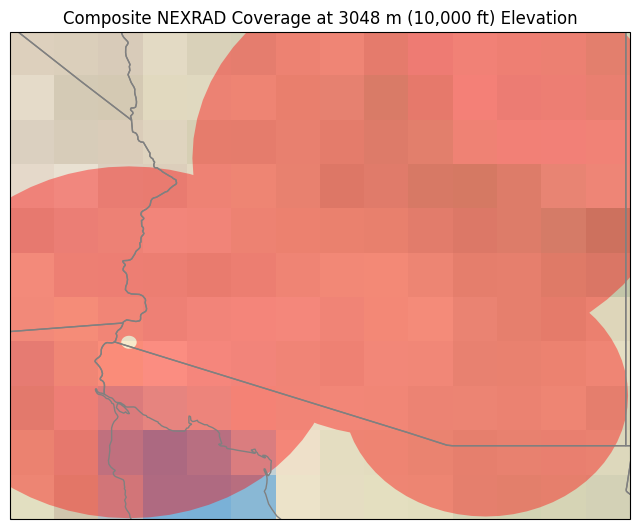

In [5]:
from tatc.analysis import compute_radar_track

composite = compute_radar_track(stations, elevation=3048)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.PlateCarree()})
composite.plot(
    facecolor="r", edgecolor="none", alpha=0.4, zorder=1, ax=ax, transform=ccrs.PlateCarree()
)
ax.stock_img()
ax.add_feature(cfeature.STATES, edgecolor="gray")
ax.set_extent([-116, -109, 30.5, 36], crs=ccrs.PlateCarree())
ax.set_title("Composite NEXRAD Coverage at 3048 m (10,000 ft) Elevation")
plt.show()

## Terrain-Masked Coverage

The examples above assume an idealized, azimuthally symmetric radar: a clear line of sight in every direction. Real terrain can block a station's lowest scan angles in specific directions. The `tatc.preprocess` module (installed via `pip install tatc[preprocess]`) derives a `TerrainMask` for a station by ray-tracing a digital elevation model (DEM): at each sampled azimuth, it finds the highest terrain obstruction within a search radius and reports the elevation angle needed to clear it.

This example uses the [Copernicus DEM GLO-30](https://registry.opendata.aws/copernicus-dem/) dataset: a public, global, 30-meter-resolution DEM requiring no authentication, accessed directly over the network as Cloud-Optimized GeoTIFFs. `get_copernicus_dem_tile_urls` identifies the tile(s) covering a search region around a station.

Computing a terrain mask this way requires fetching and ray-tracing real elevation data over the network, which typically takes about 5 minutes for all four stations. Each mask samples every 1 degree of azimuth out to 100 km, with `compute_terrain_mask`'s default of 400 geometrically spaced range samples (about 12 m apart at 1 km, growing to about 1.2 km at 100 km): in this mountainous region, terrain 50 to 100 km away often sets the blocking angle, while dense sampling close to a station avoids skipping narrow nearby ridge crests, where small sampling errors produce the largest angle errors. To keep this notebook quick to re-run, the terrain masks are precomputed and stored in `nexrad_phoenix_terrain_masks.json` alongside this notebook; the cell below loads them by default. Set `REGENERATE_TERRAIN_MASKS = True` to instead (re)derive them from the DEM, which also serves as a self-contained example of how that file was generated.

In [6]:
import json

from tatc.schemas import TerrainMask

TERRAIN_MASK_PATH = "nexrad_phoenix_terrain_masks.json"
REGENERATE_TERRAIN_MASKS = False  # set True to re-derive from the DEM over the network

if REGENERATE_TERRAIN_MASKS:
    from tatc.preprocess import get_copernicus_dem_tile_urls, compute_terrain_mask_for_station

    terrain_masks = {}
    for station in stations:
        dem_urls = get_copernicus_dem_tile_urls(station.longitude, station.latitude, radius=100000)
        station.terrain_mask = compute_terrain_mask_for_station(dem_urls, station, search_radius=100000)
        terrain_masks[station.name] = station.terrain_mask.model_dump()
    # persist for reuse, so subsequent runs do not need to repeat the DEM fetch
    with open(TERRAIN_MASK_PATH, "w", encoding="utf-8") as f:
        json.dump(terrain_masks, f, indent=2)
else:
    with open(TERRAIN_MASK_PATH, encoding="utf-8") as f:
        terrain_masks = json.load(f)
    for station in stations:
        station.terrain_mask = TerrainMask(**terrain_masks[station.name])

display(stations[0].terrain_mask)

TerrainMask(azimuth=[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0, 101.0, 102.0, 103.0, 104.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 120.0, 121.0, 122.0, 123.0, 124.0, 125.0, 126.0, 127.0, 128.0, 129.0, 130.0, 131.0, 132.0, 133.0, 134.0, 135.0, 136.0, 137.0, 138.0, 139.0, 140.0, 141.0, 142.0, 143.0, 144.0, 145.0, 146.0, 147.0, 148.0, 149.0, 150.0, 151.0, 152.0, 153.0, 154.0, 155.

Each station's terrain mask can be inspected directly: the polar plot below shows the DEM-derived minimum usable elevation angle as a function of azimuth for each station, highlighting directions where terrain blocks the lower part of the lowest beam, raising the lowest observable elevation angle above the bottom of that beam (`min_elevation_angle - beam_width / 2`).

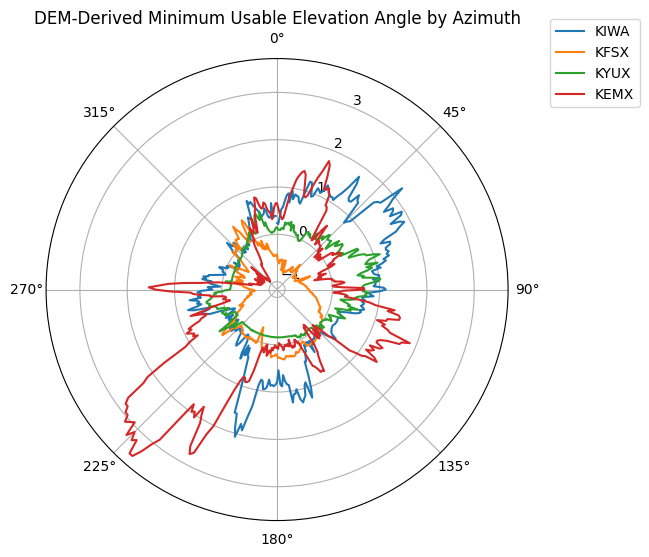

In [7]:
import numpy as np

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"})
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
for station in stations:
    azimuth_rad = np.radians(station.terrain_mask.azimuth)
    ax.plot(azimuth_rad, station.terrain_mask.min_elevation_angle, label=station.name)
ax.set_title("DEM-Derived Minimum Usable Elevation Angle by Azimuth")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()

Recomputing `collect_radar_track` with these (now terrain-masked) stations reflects terrain blockage. Directions behind terrain show reduced range because a raised scan angle climbs away from the target elevation sooner. The area lost to blockage grows with target elevation, although the fraction of each footprint lost is largest at the lowest elevations. The plots below compare coverage at several target elevations.

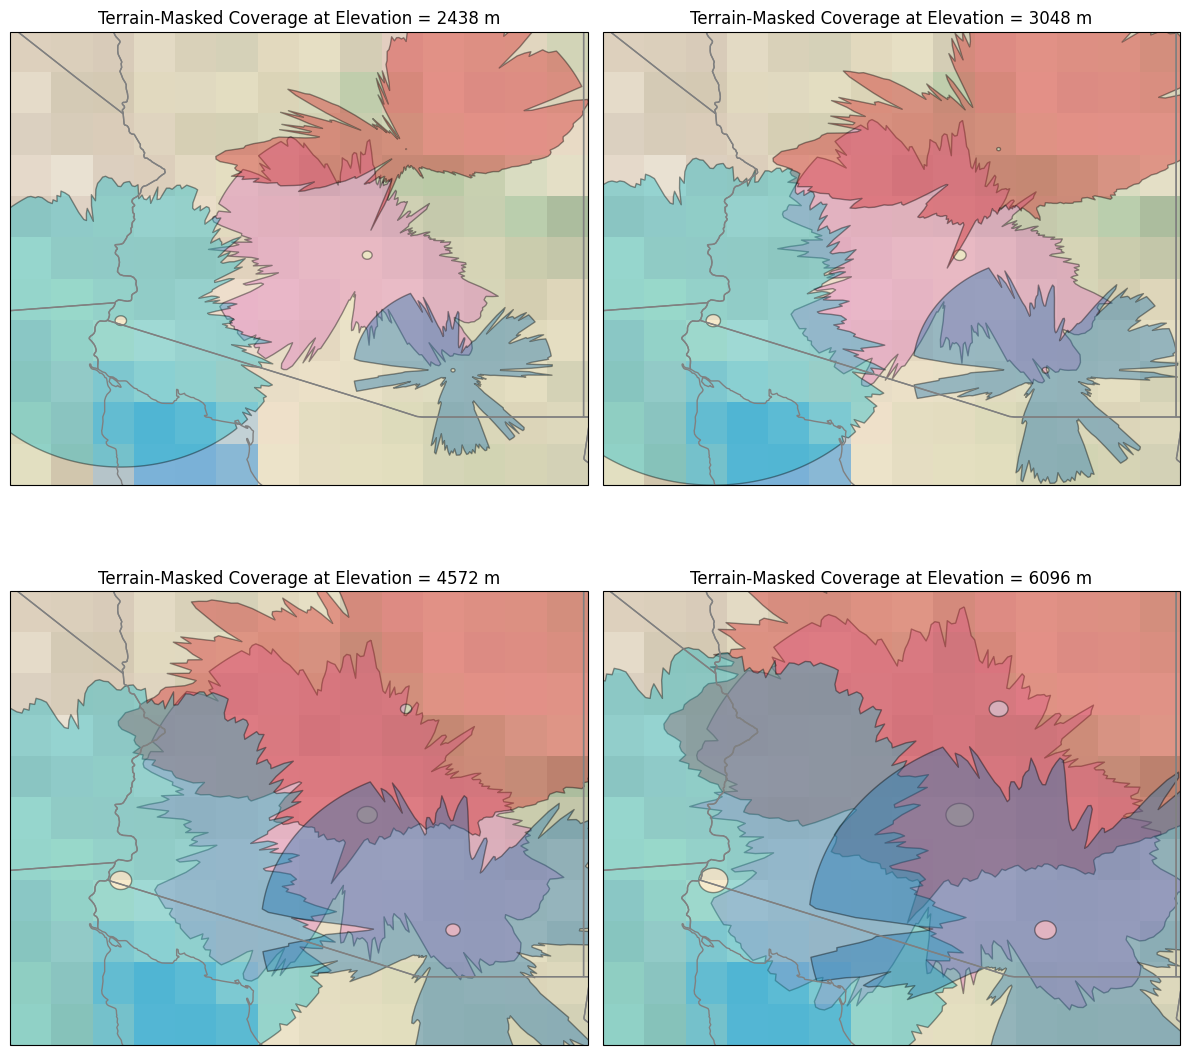

In [8]:
heights = [2438, 3048, 4572, 6096]

fig, axes = plt.subplots(2, 2, figsize=(12, 12), subplot_kw={"projection": ccrs.PlateCarree()})
for ax, height in zip(axes.flat, heights):
    results_h = collect_radar_track(stations, elevation=height)
    results_h.plot(
        column="station",
        edgecolor="k",
        alpha=0.4,
        cmap="tab10",
        ax=ax,
        transform=ccrs.PlateCarree(),
    )
    ax.stock_img()
    ax.add_feature(cfeature.STATES, edgecolor="gray")
    ax.set_extent([-116, -109, 30.5, 36], crs=ccrs.PlateCarree())
    ax.set_title(f"Terrain-Masked Coverage at Elevation = {height} m")
plt.tight_layout()
plt.show()

The composite regional coverage, recomputed with `compute_radar_track` at the same 3048 m (10,000 ft) benchmark elevation, now reflects the combined effect of all four stations' terrain masks alongside any cones of silence that neighboring stations do not fill.

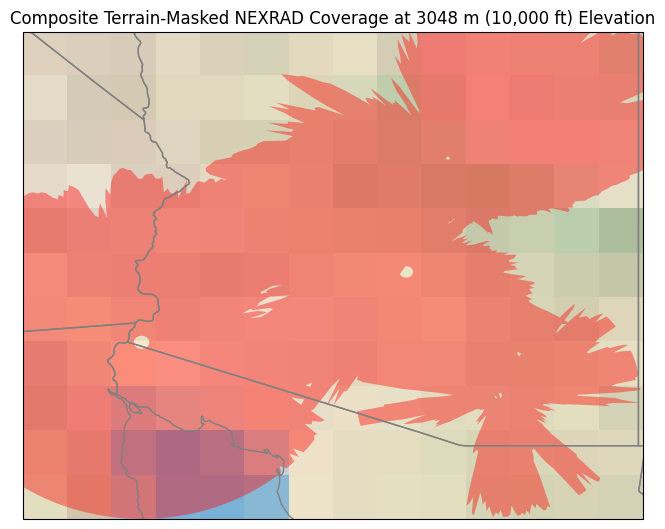

In [9]:
composite_masked = compute_radar_track(stations, elevation=3048)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.PlateCarree()})
composite_masked.plot(
    facecolor="r", edgecolor="none", alpha=0.4, zorder=1, ax=ax, transform=ccrs.PlateCarree()
)
ax.stock_img()
ax.add_feature(cfeature.STATES, edgecolor="gray")
ax.set_extent([-116, -109, 30.5, 36], crs=ccrs.PlateCarree())
ax.set_title("Composite Terrain-Masked NEXRAD Coverage at 3048 m (10,000 ft) Elevation")
plt.show()

## Comparing Radar Bands

Band choice is one of the most consequential practical design decisions for a weather radar network: it governs the tradeoff between maximum useful range and sensitivity to rain attenuation. S-band (NEXRAD's choice) suffers negligible attenuation even in heavy rain and so supports the longest range; C-band attenuates moderately; X-band attenuates severely enough that a heavy storm core can all but extinguish the signal a comparatively short distance behind it, though it allows much smaller, cheaper antennas and is common in short-range gap-filling and mobile networks.

TAT-C does not model attenuation as a transient, weather-dependent effect (see the `RadarBand` documentation), so it cannot show a storm "eating into" an X-band radar's effective range on a given day. What it can show is the static, illustrative nominal range difference baked into `RadarStation.from_band`: a hypothetical S-band, C-band, and X-band station, all sited at `KIWA`'s location, are compared below at 6,096 m (20,000 ft). There, the C-band and X-band footprints are limited by their shorter nominal ranges, while the S-band footprint ends where its lowest beam climbs above the target elevation, well inside its 460 km range.

,station,band,outer_ground_range
0,S-band,S,306364.275546
1,C-band,C,149983.242840
2,X-band,X,59998.811624


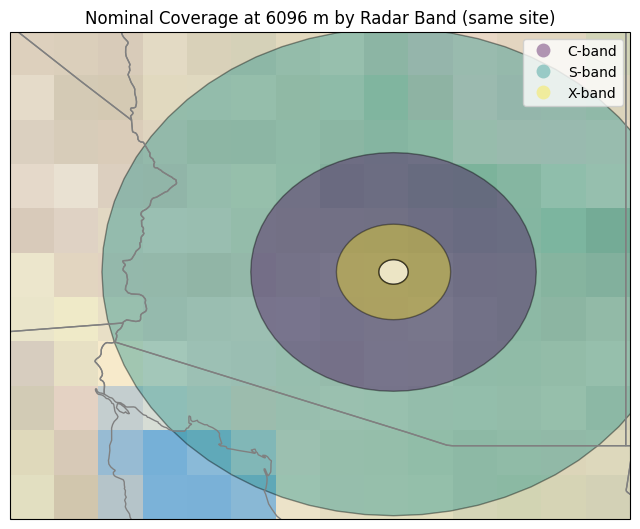

In [10]:
s_band = RadarStation.from_band(RadarBand.S, name="S-band", latitude=stations[0].latitude, longitude=stations[0].longitude, elevation=stations[0].elevation)
c_band = RadarStation.from_band(RadarBand.C, name="C-band", latitude=stations[0].latitude, longitude=stations[0].longitude, elevation=stations[0].elevation)
x_band = RadarStation.from_band(RadarBand.X, name="X-band", latitude=stations[0].latitude, longitude=stations[0].longitude, elevation=stations[0].elevation)

band_results = collect_radar_track([s_band, c_band, x_band], elevation=6096)
display(band_results[["station", "band", "outer_ground_range"]])

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.PlateCarree()})
band_results.plot(
    column="station",
    edgecolor="k",
    alpha=0.4,
    legend=True,
    cmap="viridis",
    ax=ax,
    transform=ccrs.PlateCarree(),
)
ax.stock_img()
ax.add_feature(cfeature.STATES, edgecolor="gray")
ax.set_extent([-116, -109, 30.5, 36], crs=ccrs.PlateCarree())
ax.set_title("Nominal Coverage at 6096 m by Radar Band (same site)")
plt.show()